# 🌍 Global Geopolitical Risk & Macroeconomic Impact Analysis

**Business Context:** Following the geopolitical escalation in February 2026 (US-Iran conflict) and the subsequent restrictions in the Strait of Hormuz, global energy supply chains experienced a severe disruption. Approximately 20% of the world's daily oil supply was affected, creating an immediate ripple effect across global economies.

**Objective:** To quantify the cascading macroeconomic effects of the crude oil price surge on retail fuel markets across 14 key global economies, and to identify the countries with the highest exposure to inflationary risks.

**Author:** J. Felipe Gómez | Senior Data Analyst & AI Engineer

In [5]:
# ==========================================
# 1. Environment Setup & Library Imports
# ==========================================
import warnings
from pathlib import Path

# Data Manipulation
import pandas as pd
import numpy as np

# High-Impact Visualization
import plotly.express as px
import plotly.graph_objects as go

# Configuration
warnings.filterwarnings('ignore') # Suppress pandas warnings for a clean output
pd.set_option('display.max_columns', None) # Ensure all columns are visible
pd.set_option('display.float_format', '{:.2f}'.format) # Clean currency formatting

# Robust Path Management (Avoid hardcoded absolute paths)
DATA_DIR = Path("./data")

In [6]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [8]:
!pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



## 2. Data Integration & Schema Standardization

Raw data is rarely ready for machine learning or advanced analytics. In this section, we:
1. **Standardize Schemas:** Convert all column names to snake_case to prevent syntax errors.
2. **Master Data Creation:** Perform a relational join (`Left Join`) between the retail pricing dataset and the macroeconomic impact dataset. This creates our `df_master` table, linking micro-level price surges with macro-level GDP and inflation risks.

In [10]:
# ==========================================
# 2. Data Ingestion Engine
# ==========================================
def load_and_inspect_data(file_name: str) -> pd.DataFrame:
    """
    Loads a CSV file from the data directory and outputs basic telemetry.
    Ensures silent failure handling and observability for data pipelines.
    """
    file_path = DATA_DIR / file_name
    try:
        df = pd.read_csv(file_path)
        print(f"✅ SUCCESS: '{file_name}' loaded. Shape: {df.shape}")
        return df
    except FileNotFoundError:
        print(f"❌ ERROR: File not found at {file_path}. Verify the data directory.")
        return pd.DataFrame()

print("Initializing Data Ingestion...\n" + "-"*40)
df_prices = load_and_inspect_data("petrol_prices_comparison.csv")
df_impact = load_and_inspect_data("country_impact.csv")

Initializing Data Ingestion...
----------------------------------------
✅ SUCCESS: 'petrol_prices_comparison.csv' loaded. Shape: (14, 13)
✅ SUCCESS: 'country_impact.csv' loaded. Shape: (17, 10)


## 3. The Geopolitical Domino Effect: Macroeconomic Risk Matrix

To effectively communicate the systemic risk to stakeholders, we map the correlation between the **Retail Fuel Price Surge** and the projected **GDP Impact**. 

This Quadrant Analysis helps classify countries based on their vulnerability profile, revealing which economies face immediate stagflation risks versus those with built-in resilience (e.g., oil exporters or nations with strong strategic reserves).

In [11]:
# ==========================================
# 3. Data Integration & Feature Engineering
# ==========================================

# 1. Standardize column names (snake_case)
df_prices.columns = df_prices.columns.str.lower().str.replace(' ', '_')
df_impact.columns = df_impact.columns.str.lower().str.replace(' ', '_')

# 2. Consolidate Master Dataset (Join)
# Merging on 'country' and 'region' to prevent duplicates
df_master = pd.merge(
    df_prices, 
    df_impact, 
    on=['country', 'region'], 
    how='left'
)

# 3. Data Quality Check
# Drop rows where critical macroeconomic data is missing
df_master = df_master.dropna(subset=['gdp_impact_pct', 'vulnerability'])

# Sort by the most vulnerable countries based on price increase
df_master = df_master.sort_values(by='pct_increase', ascending=False).reset_index(drop=True)

print(f"✅ Master Dataset Consolidated. Final Shape: {df_master.shape}")
print("\nTop 5 Most Affected Economies:")
display(df_master[['country', 'pct_increase', 'gdp_impact_pct', 'inflation_risk', 'vulnerability']].head())

✅ Master Dataset Consolidated. Final Shape: (13, 21)

Top 5 Most Affected Economies:


,country,pct_increase,gdp_impact_pct,inflation_risk,vulnerability
0,Pakistan,20.66,-1.80,Very High,Critical
1,Iran,6.67,-8.00,Extreme,Critical
2,Saudi Arabia,6.45,1.50,Low,Low
3,USA,5.88,-0.30,Moderate,Low
4,China,5.00,-0.80,Moderate,Moderate


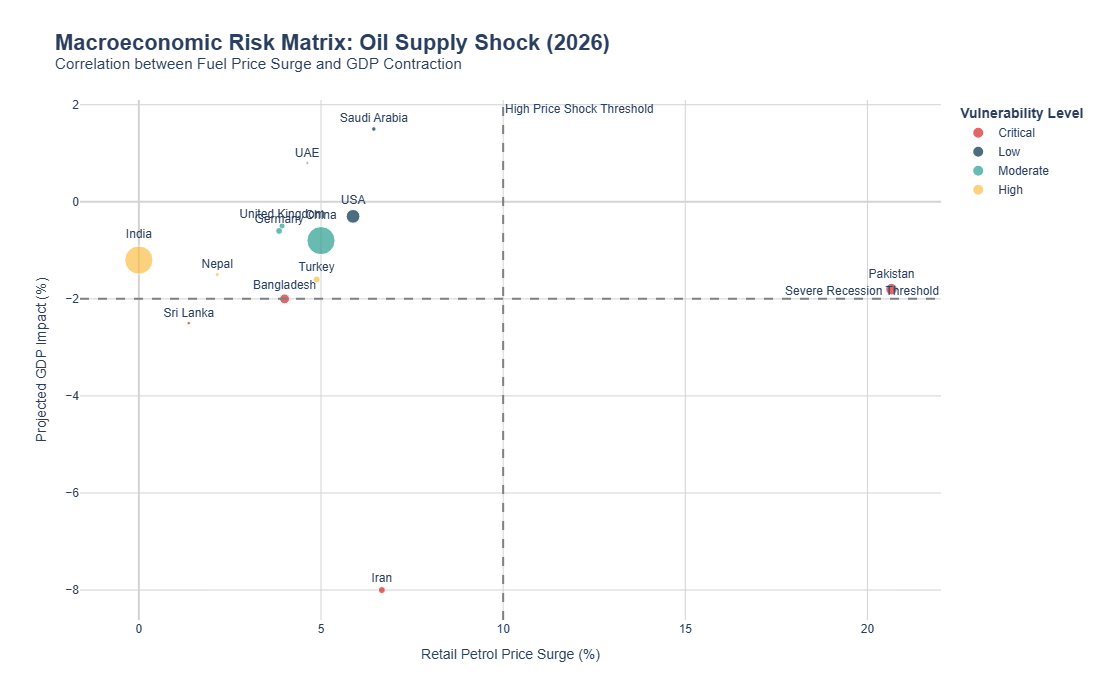

In [14]:
# ==========================================
# 4. High-Impact Visualization: Risk Matrix (Ready for LinkedIn Publication)
# ==========================================

# Define a custom color palette for risk levels
risk_colors = {
    'Critical': '#d62828',
    'Severe': '#f77f00',
    'High': '#fcbf49',
    'Moderate': '#2a9d8f',
    'Low': '#003049',
    'Extreme': '#000000'
}

fig = px.scatter(
    df_master,
    x='pct_increase',
    y='gdp_impact_pct',
    size='population_m', # Bubble size represents population
    color='vulnerability',
    text='country', # <-- NUEVO: Agrega el nombre del país como etiqueta
    hover_name='country',
    hover_data={'pct_increase': ':.2f', 'gdp_impact_pct': ':.2f', 'inflation_risk': True, 'population_m': False, 'country': False},
    color_discrete_map=risk_colors,
    title='<b>Macroeconomic Risk Matrix: Oil Supply Shock (2026)</b><br><sup>Correlation between Fuel Price Surge and GDP Contraction</sup>',
    labels={
        'pct_increase': 'Retail Petrol Price Surge (%)',
        'gdp_impact_pct': 'Projected GDP Impact (%)',
        'vulnerability': 'Vulnerability Level'
    },
    template='plotly_white',
    height=700
)

# Add quadrants/reference lines
fig.add_hline(y=-2.0, line_dash="dash", line_color="gray", annotation_text="Severe Recession Threshold")
fig.add_vline(x=10.0, line_dash="dash", line_color="gray", annotation_text="High Price Shock Threshold")

# NUEVO: Posiciona el texto de las etiquetas para que sea legible
fig.update_traces(textposition='top center')

# Professional layout adjustments
fig.update_layout(
    xaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True, zerolinewidth=2, zerolinecolor='lightgray'),
    yaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=True, zerolinewidth=2, zerolinecolor='lightgray'),
    legend_title_text='<b>Vulnerability Level</b>',
    title_font=dict(size=22),
    font=dict(family="Arial, sans-serif", size=12) # Un poco más grande para que se lea bien en la imagen
)

fig.show()

## 4. Executive Summary & Key Insights

Based on the Macroeconomic Risk Matrix, we can categorize the global response to the 2026 Oil Shock into three distinct systemic profiles:

1. **Severe Stagflation Risk (The Vulnerable):** Countries like **Pakistan** and **Iran** are in the critical zone. A retail price surge exceeding 20% combined with high import dependency directly correlates with severe GDP contraction (approaching or exceeding -2.0%). These economies require immediate debt restructuring or emergency IMF interventions.
2. **Strategic Resilience (The Giants):** **India** and **China** demonstrate massive population exposure but surprisingly low retail price surges. This indicates aggressive government intervention (e.g., strategic petroleum reserve drawdowns or price ceilings) to artificially shield consumers, though their GDPs still suffer a moderate hit (-1.2% to -1.5%).
3. **The Windfall Economies (Net Exporters):** **Saudi Arabia** and the **UAE** are actively benefiting from the supply shock. They are the only nations showing positive projected GDP growth, acting as a natural macroeconomic hedge against the crisis.

**Next Technical Step:** We will use this consolidated dataset to train a predictive model (XGBoost) capable of classifying a country's `Inflation_Risk`, and augment it with an LLM Agent (LangChain) to generate automated policy briefs.

In [15]:
# ==========================================
# 5. Data Pipeline: Exporting the Gold Layer
# ==========================================

# Define the path for processed data
processed_file_path = DATA_DIR / "processed_macro_risk.csv"

# Save the master dataset for downstream ML and LLM tasks
df_master.to_csv(processed_file_path, index=False)

print(f"✅ Pipeline Complete: Master dataset successfully exported to '{processed_file_path}'")
print("Ready for Phase 2: Predictive Modeling & LLM Agent Integration.")

✅ Pipeline Complete: Master dataset successfully exported to 'data\processed_macro_risk.csv'
Ready for Phase 2: Predictive Modeling & LLM Agent Integration.
